In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({"figure.figsize": (13, 4), "axes.grid": True, "grid.alpha": .3})

# ===== Cấu hình =====
TICKER, PERIOD = "VIC.VN", "2y"
TEST_SIZE = 30      
WINDOW    = 250     
P_MAX, Q_MAX = 4, 4
FORECAST  = 10

## 1. Tải dữ liệu & vẽ giá

521 phiên | 2024-06-03 → 2026-06-01


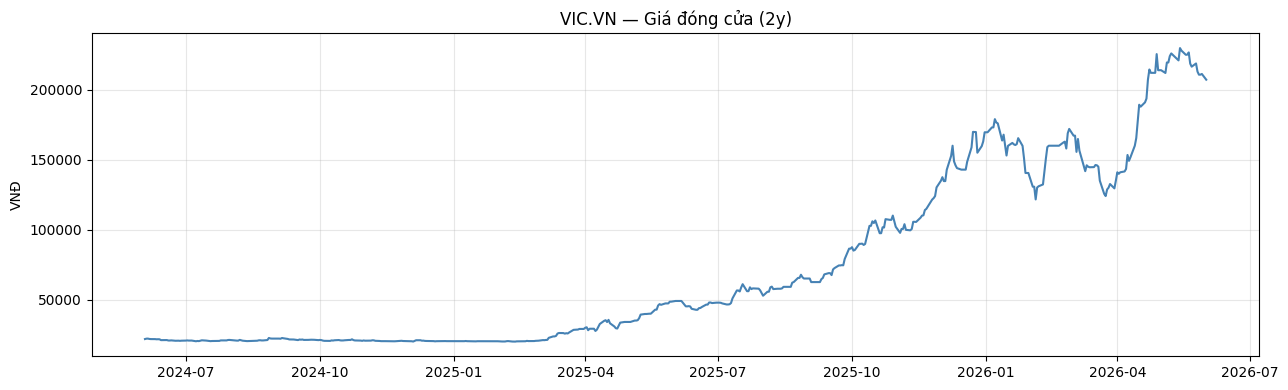

In [ ]:
raw = yf.download(TICKER, period=PERIOD, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
close = raw["Close"].astype(float).dropna()
print(f"{len(close)} phiên | {close.index[0].date()} → {close.index[-1].date()}")

plt.plot(close, color="steelblue", lw=1.5)
plt.title(f"{TICKER} — Giá đóng cửa ({PERIOD})"); plt.ylabel("VNĐ")
plt.tight_layout(); plt.show()

## 2. Kiểm định ADF


=== ADF ===
Log-giá    | ADF=   0.641 | p=0.9886 | ❌ không dừng
Sai phân 1 | ADF= -19.507 | p=0.0000 | ✅ dừng


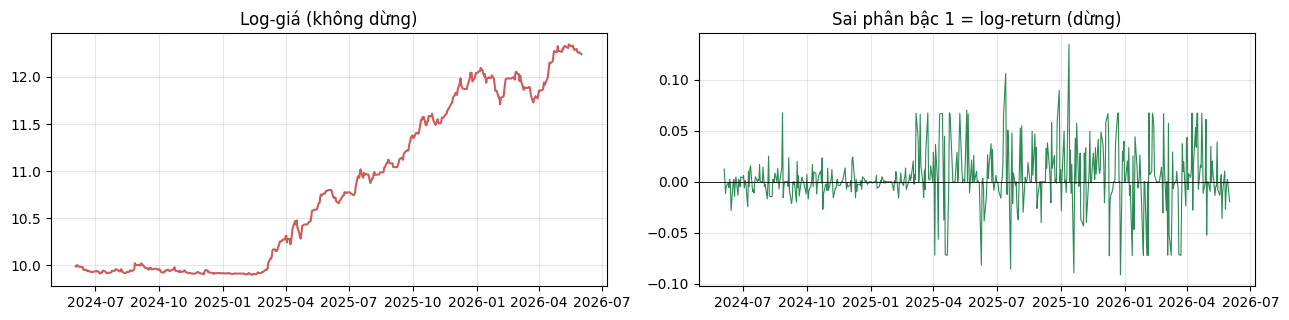

In [ ]:
log_price = np.log(close)
diff1     = log_price.diff().dropna()      # = log-return = phần ARIMA tự sai phân khi d=1

def adf(s, name):
    stat, p, *_ = adfuller(s.dropna())
    print(f"{name:11s}| ADF={stat:8.3f} | p={p:.4f} | {'✅ dừng' if p<0.05 else '❌ không dừng'}")

print("=== ADF ===")
adf(log_price, "Log-giá")
adf(diff1,     "Sai phân 1")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.3))
ax[0].plot(log_price, color="indianred");          ax[0].set_title("Log-giá (không dừng)")
ax[1].plot(diff1, color="seagreen", lw=.8); ax[1].axhline(0, color="k", lw=.6)
ax[1].set_title("Sai phân bậc 1 = log-return (dừng)")
plt.tight_layout(); plt.show()

## 3. ACF & PACF → chọn `p, q`



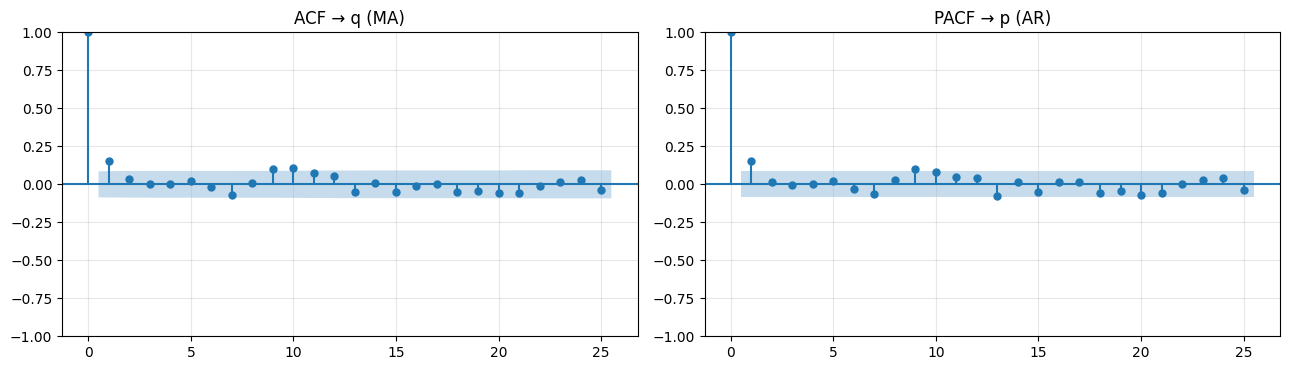

Dải tin cậy ±0.086
Lag ACF  vượt dải: [1, 9, 10]
Lag PACF vượt dải: [1, 9]


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
plot_acf(diff1, ax=ax[0], lags=25);              ax[0].set_title("ACF → q (MA)")
plot_pacf(diff1, ax=ax[1], lags=25, method="ywm"); ax[1].set_title("PACF → p (AR)")
plt.tight_layout(); plt.show()

ci = 1.96/np.sqrt(len(diff1))
a, p = acf(diff1, nlags=25), pacf(diff1, nlags=25, method="ywm")
print(f"Dải tin cậy ±{ci:.3f}")
print("Lag ACF  vượt dải:", [i for i in range(1,26) if abs(a[i])>ci] or "không có → q nhỏ")
print("Lag PACF vượt dải:", [i for i in range(1,26) if abs(p[i])>ci] or "không có → p nhỏ")

## 4. Grid-search chọn `(p, q)` theo **AIC**


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 p  q          AIC
 1  0 -2122.626738
 0  1 -2121.908110
 0  2 -2120.847639
 2  0 -2120.714211
 1  1 -2120.695365
 3  0 -2118.903169

✅ Tốt nhất: ARIMA(1,1,0) | AIC = -2122.63


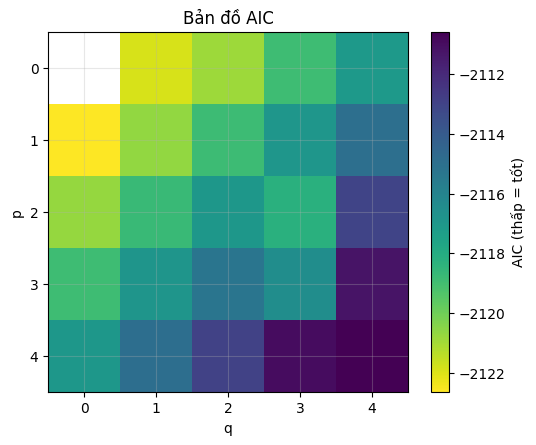

In [ ]:
train = close.iloc[:-TEST_SIZE]
lp_train = np.log(train.values.astype(float))

rows = []
for p in range(P_MAX+1):
    for q in range(Q_MAX+1):
        if p == q == 0: continue
        try:
            rows.append({"p": p, "q": q,
                         "AIC": ARIMA(lp_train, order=(p,1,q), trend="t").fit().aic})
        except Exception: pass

tbl = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
P_BEST, Q_BEST = int(tbl.p[0]), int(tbl.q[0])
print(tbl.head(6).to_string(index=False))
print(f"\n✅ Tốt nhất: ARIMA({P_BEST},1,{Q_BEST}) | AIC = {tbl.AIC[0]:.2f}")

piv = tbl.pivot(index="p", columns="q", values="AIC")
plt.figure(figsize=(5.5, 4.5))
plt.imshow(piv, cmap="viridis_r"); plt.colorbar(label="AIC (thấp = tốt)")
plt.xticks(range(len(piv.columns)), piv.columns); plt.yticks(range(len(piv.index)), piv.index)
plt.xlabel("q"); plt.ylabel("p"); plt.title("Bản đồ AIC")
plt.tight_layout(); plt.show()

## 5. Kiểm tra phần dư

Ljung–Box (lag 10): p = 1.0000 → ✅ ~ nhiễu trắng


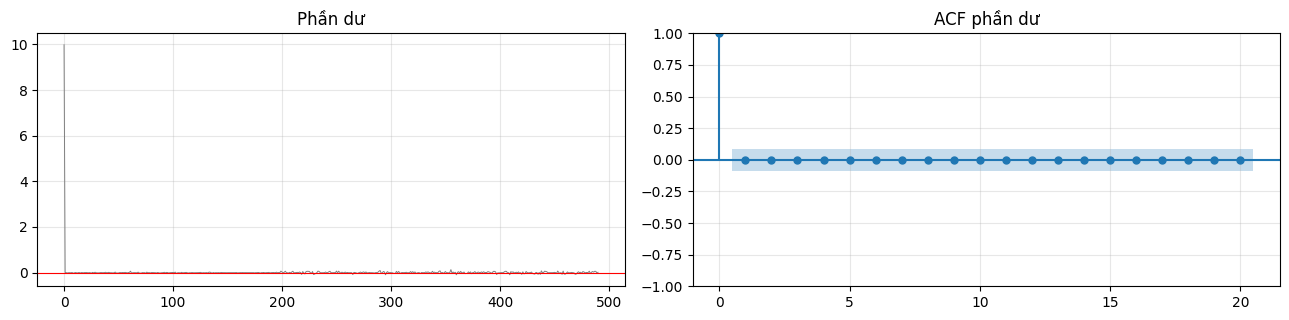

In [ ]:
model = ARIMA(lp_train, order=(P_BEST,1,Q_BEST), trend="t").fit()
resid = pd.Series(model.resid)
lb = acorr_ljungbox(resid, lags=[10], return_df=True)["lb_pvalue"].iloc[0]
print(f"Ljung–Box (lag 10): p = {lb:.4f} →",
      "✅ ~ nhiễu trắng" if lb > 0.05 else "⚠️ còn tự tương quan")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.3))
ax[0].plot(resid, color="gray", lw=.7); ax[0].axhline(0, color="red", lw=.8)
ax[0].set_title("Phần dư")
plot_acf(resid, ax=ax[1], lags=20); ax[1].set_title("ACF phần dư")
plt.tight_layout(); plt.show()

## 6. Backtest bằng **Sliding Window** (walk-forward 1 bước)

Cửa sổ `WINDOW` phiên trượt dần. Mỗi phiên test: fit ARIMA trên cửa sổ → **dự báo 1 bước**
log-giá → `exp()` ra **giá** → nạp giá thật vào, trượt tiếp. Đánh giá out-of-sample trung thực.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,1,0) | MAE=4,070 | RMSE=5,560 | MAPE=1.87%


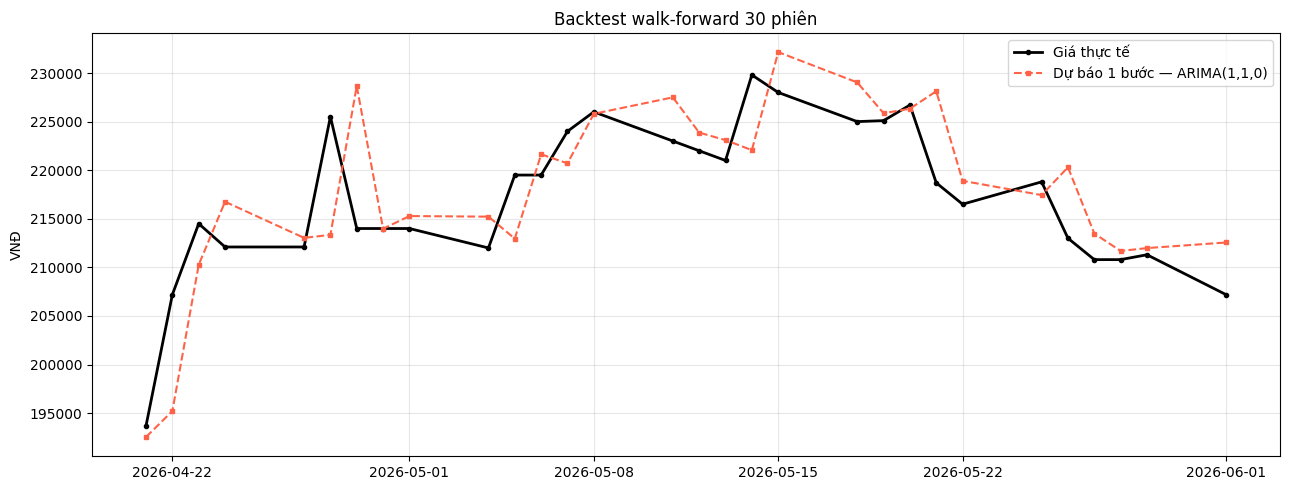

In [ ]:
def sliding_backtest(prices, order, window, test_size):
    lp = np.log(prices.values.astype(float)); n = len(prices)
    pred, idx = [], []
    for t in range(n - test_size, n):
        m = ARIMA(lp[t-window:t], order=order, trend="t").fit()
        lp_hat = float(np.asarray(m.forecast(1)).ravel()[0])
        pred.append(np.exp(lp_hat)); idx.append(prices.index[t])      # exp → về giá gốc
    return pd.Series(pred, index=idx), prices.iloc[-test_size:]

def score(actual, pred):
    a, p = actual.values.astype(float), pred.values.astype(float)
    return (mean_absolute_error(a, p), np.sqrt(mean_squared_error(a, p)),
            np.mean(np.abs((a-p)/a))*100)

pred, actual = sliding_backtest(close, (P_BEST,1,Q_BEST), WINDOW, TEST_SIZE)
mae, rmse, mape = score(actual, pred)
print(f"ARIMA({P_BEST},1,{Q_BEST}) | MAE={mae:,.0f} | RMSE={rmse:,.0f} | MAPE={mape:.2f}%")

plt.figure(figsize=(13, 5))
plt.plot(actual, "o-", color="black", ms=3, lw=2, label="Giá thực tế")
plt.plot(pred, "s--", color="tomato", ms=3, label=f"Dự báo 1 bước — ARIMA({P_BEST},1,{Q_BEST})")
plt.title(f"Backtest walk-forward {TEST_SIZE} phiên"); plt.ylabel("VNĐ"); plt.legend()
plt.tight_layout(); plt.show()

## 7. So sánh AR vs MA vs ARIMA (đều chọn bậc bằng AIC)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

     Mô hình   MAE  RMSE  MAPE
       AR(1) 4,070 5,560 1.87%
       MA(1) 4,071 5,546 1.88%
ARIMA(1,1,1) 4,078 5,560 1.88%

🏆 Tốt nhất: MA(1)


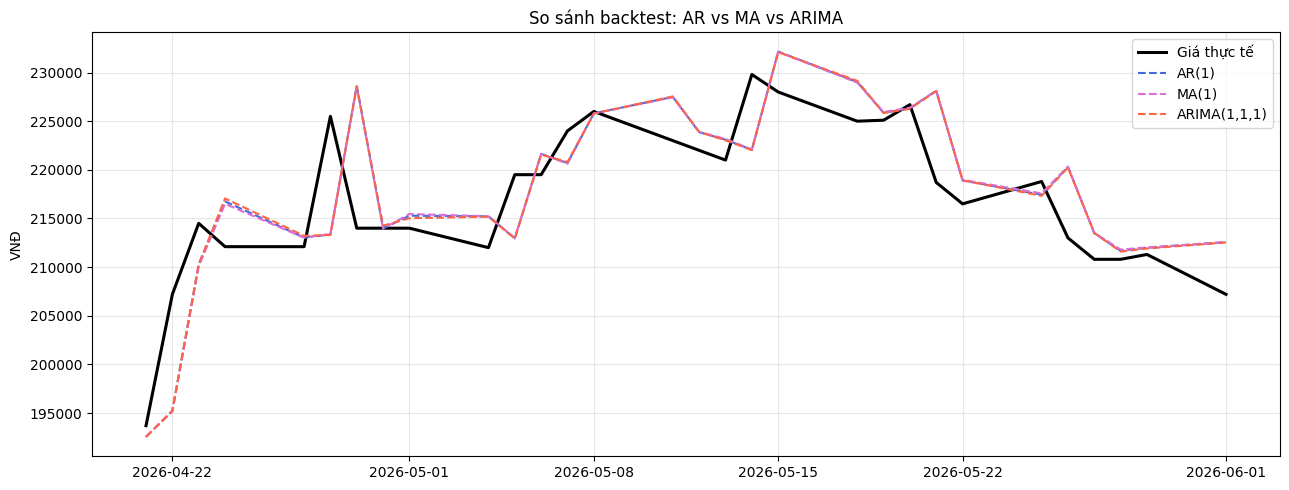

In [ ]:
def best_order(family):
    cands = {"AR":   [(p,1,0) for p in range(1,P_MAX+1)],
             "MA":   [(0,1,q) for q in range(1,Q_MAX+1)],
             "ARIMA":[(p,1,q) for p in range(1,P_MAX+1) for q in range(1,Q_MAX+1)]}[family]
    best, ba = None, np.inf
    for o in cands:
        try:
            a = ARIMA(lp_train, order=o, trend="t").fit().aic
            if a < ba: ba, best = a, o
        except Exception: pass
    return best

rows, preds = [], []
for fam in ["AR", "MA", "ARIMA"]:
    o = best_order(fam)
    pr, ac = sliding_backtest(close, o, WINDOW, TEST_SIZE)
    mae, rmse, mape = score(ac, pr)
    name = f"AR({o[0]})" if fam=="AR" else f"MA({o[2]})" if fam=="MA" else f"ARIMA({o[0]},1,{o[2]})"
    rows.append({"Mô hình": name, "MAE": f"{mae:,.0f}", "RMSE": f"{rmse:,.0f}",
                 "MAPE": f"{mape:.2f}%", "_rmse": rmse})
    preds.append((name, pr))

cmp = pd.DataFrame(rows)
print(cmp[["Mô hình","MAE","RMSE","MAPE"]].to_string(index=False))
winner = cmp.loc[cmp["_rmse"].idxmin(), "Mô hình"]
print(f"\n🏆 Tốt nhất: {winner}")

plt.figure(figsize=(13, 5))
plt.plot(actual, color="black", lw=2.2, label="Giá thực tế")
for (name, pr), c in zip(preds, ["royalblue","orchid","tomato"]):
    plt.plot(pr, "--", lw=1.5, color=c, label=name)
plt.title("So sánh backtest: AR vs MA vs ARIMA"); plt.ylabel("VNĐ"); plt.legend()
plt.tight_layout(); plt.show()

## 8. Dự báo tương lai

Fit lại trên **toàn bộ** dữ liệu, dự báo `FORECAST` phiên, `exp()` về giá kèm khoảng tin cậy 95%.

=== Dự báo 10 phiên — ARIMA(1,1,0) ===
  2026-06-02 →    207,347  [196,482 – 218,812]
  2026-06-03 →    208,132  [191,731 – 225,935]
  2026-06-04 →    209,018  [188,449 – 231,831]
  2026-06-05 →    209,922  [185,915 – 237,029]
  2026-06-08 →    210,832  [183,838 – 241,790]
  2026-06-09 →    211,747  [182,075 – 246,254]
  2026-06-10 →    212,665  [180,542 – 250,504]
  2026-06-11 →    213,588  [179,189 – 254,590]
  2026-06-12 →    214,515  [177,980 – 258,549]
  2026-06-15 →    215,445  [176,889 – 262,406]


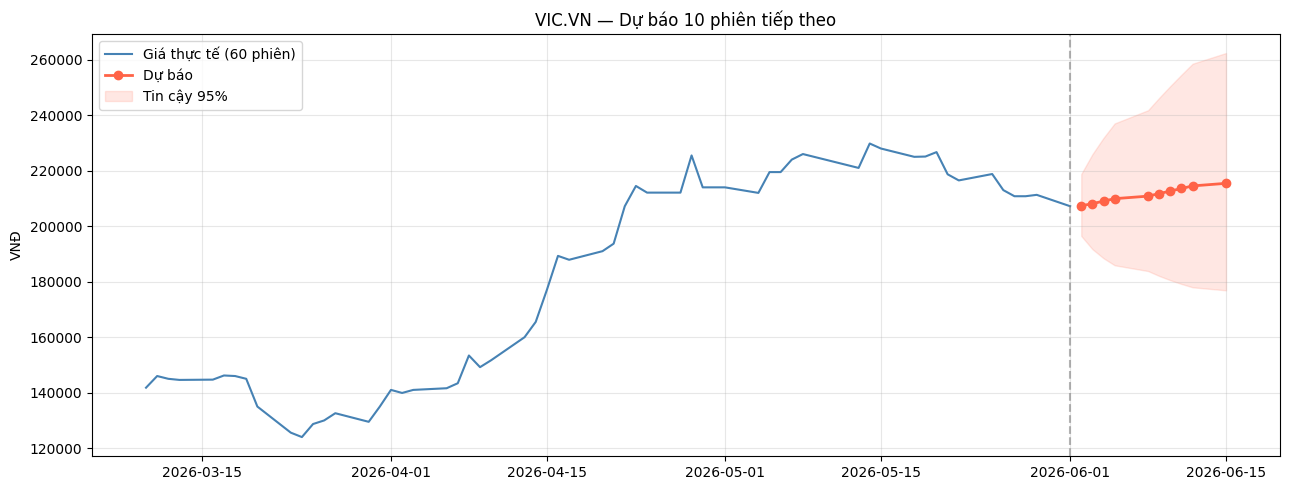

In [ ]:
m = ARIMA(np.log(close.values.astype(float)), order=(P_BEST,1,Q_BEST), trend="t").fit()
fc = m.get_forecast(FORECAST)
idx = pd.bdate_range(close.index[-1] + pd.Timedelta(days=1), periods=FORECAST)
mean = pd.Series(np.exp(fc.predicted_mean), index=idx)
ci   = np.exp(fc.conf_int())

print(f"=== Dự báo {FORECAST} phiên — ARIMA({P_BEST},1,{Q_BEST}) ===")
for d, v, lo, hi in zip(idx, mean.values, ci[:,0], ci[:,1]):
    print(f"  {d.date()} → {v:>10,.0f}  [{lo:,.0f} – {hi:,.0f}]")

plt.figure(figsize=(13, 5))
plt.plot(close.tail(60), color="steelblue", lw=1.5, label="Giá thực tế (60 phiên)")
plt.plot(mean, "o-", color="tomato", lw=2, label="Dự báo")
plt.fill_between(idx, ci[:,0], ci[:,1], color="tomato", alpha=.15, label="Tin cậy 95%")
plt.axvline(close.index[-1], color="gray", ls="--", alpha=.6)
plt.title(f"{TICKER} — Dự báo {FORECAST} phiên tiếp theo"); plt.ylabel("VNĐ"); plt.legend()
plt.tight_layout(); plt.show()